In [ ]:
! pip install pandas openpyxl # openpyxl used for to read & write excel files

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
train = pd.read_csv("/content/train_v9rqX0R.csv") # Load training dataset from CSV file into a Pandas DataFrame
test = pd.read_csv("/content/test_AbJTz2l.csv")    # Load test dataset (used for predictions later)
test1 = test.copy()
train.shape,test.shape  ## Shape of our Dataset rows and columns

((8523, 12), (5681, 11))

In [ ]:
train.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [ ]:
train.columns

Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Item_Outlet_Sales'],
      dtype='object')

In [ ]:
test["Outlet_Size"].unique()  # Find most frequent value (mode) in Outlet_Size column

array(['Medium', nan, 'Small', 'High'], dtype=object)

In [ ]:
train.nunique()

,0
Item_Identifier,1559
Item_Weight,415
Item_Fat_Content,5
Item_Visibility,7880
Item_Type,16
Item_MRP,5938
Outlet_Identifier,10
Outlet_Establishment_Year,9
Outlet_Size,3
Outlet_Location_Type,3


In [ ]:
test.nunique()

,0
Item_Identifier,1543
Item_Weight,410
Item_Fat_Content,5
Item_Visibility,5277
Item_Type,16
Item_MRP,4402
Outlet_Identifier,10
Outlet_Establishment_Year,9
Outlet_Size,3
Outlet_Location_Type,3


In [ ]:
train.isna().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


In [ ]:
map1 = {"Small":1,"Medium":2,"High":3}   # Create a dictionary to convert text categories into numbers
train["Outlet_Size"] = train["Outlet_Size"].map(map1)  # Replace text values in 'Outlet_Size' column using the mapping dictionary
train["Item_Weight"] = train["Item_Weight"].fillna(train.Item_Weight.mean()) # Replace missing values in Item_Weight with the average (mean) weight
train["Outlet_Size"] = train["Outlet_Size"].fillna(train["Outlet_Size"].median())  # Replace missing values in Outlet_Size with the median value

"Item_Weight is continuous numerical data, so I used mean imputation.
Outlet_Size is an ordinal categorical feature encoded numerically, so I used median to preserve the order."

In [ ]:
train.isna().sum()  # Count missing (NaN) values in each column of the dataset

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


In [ ]:

# Mapping dictionary
map1 = {"Small":1, "Medium":2, "High":3}

# Apply mapping (This line will cause an error if 'Outlet_Size' is already dropped)
# test["Outlet_Size"] = test["Outlet_Size"].map(map1)

# Fill missing values using TRAIN statistics
test["Item_Weight"] = test["Item_Weight"].fillna(train["Item_Weight"].mean())
# test["Outlet_Size"] = test["Outlet_Size"].fillna(train["Outlet_Size"].median()) # This line will also cause an error if 'Outlet_Size' is already dropped

In [ ]:
train.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,2.0,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,2.0,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,2.0,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,2.0,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,3.0,Tier 3,Supermarket Type1,994.7052


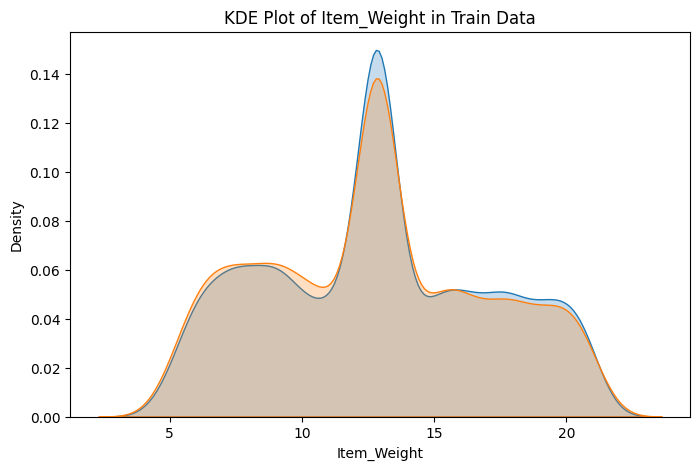

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.kdeplot(train['Item_Weight'], fill=True)
sns.kdeplot(test['Item_Weight'], fill=True)
plt.title('KDE Plot of Item_Weight in Train Data') ##Kernel Density Estimate (KDE) KDE shows smooth distribution
plt.xlabel('Item_Weight')
plt.ylabel('Density')
plt.show()

"I used KDE plots to compare the distribution of features between train and test datasets to ensure they follow a similar distribution, which is important for model generalization."

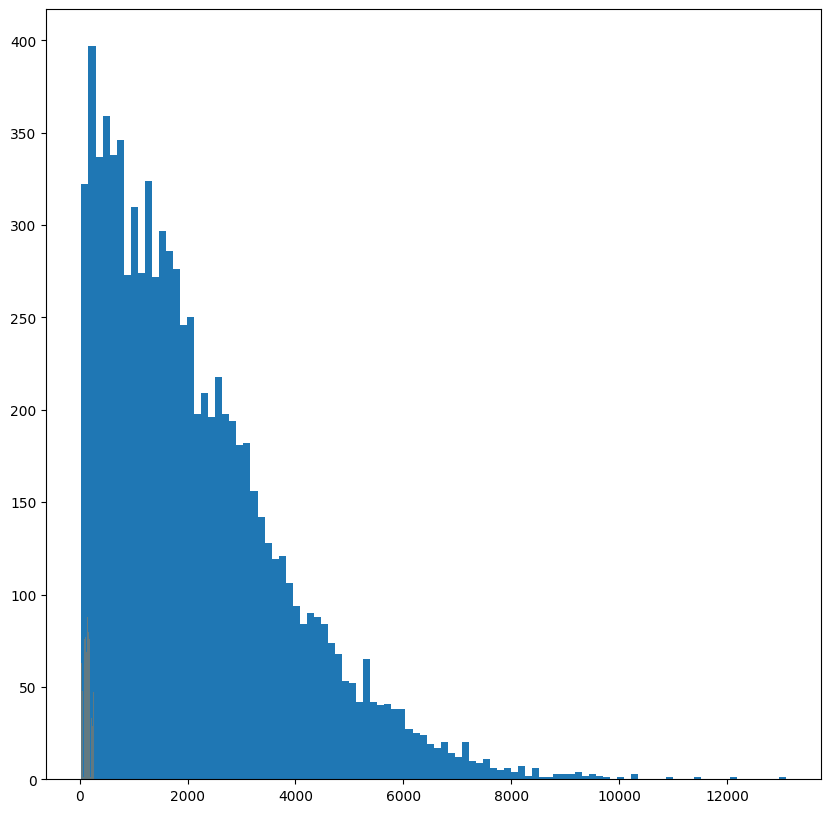

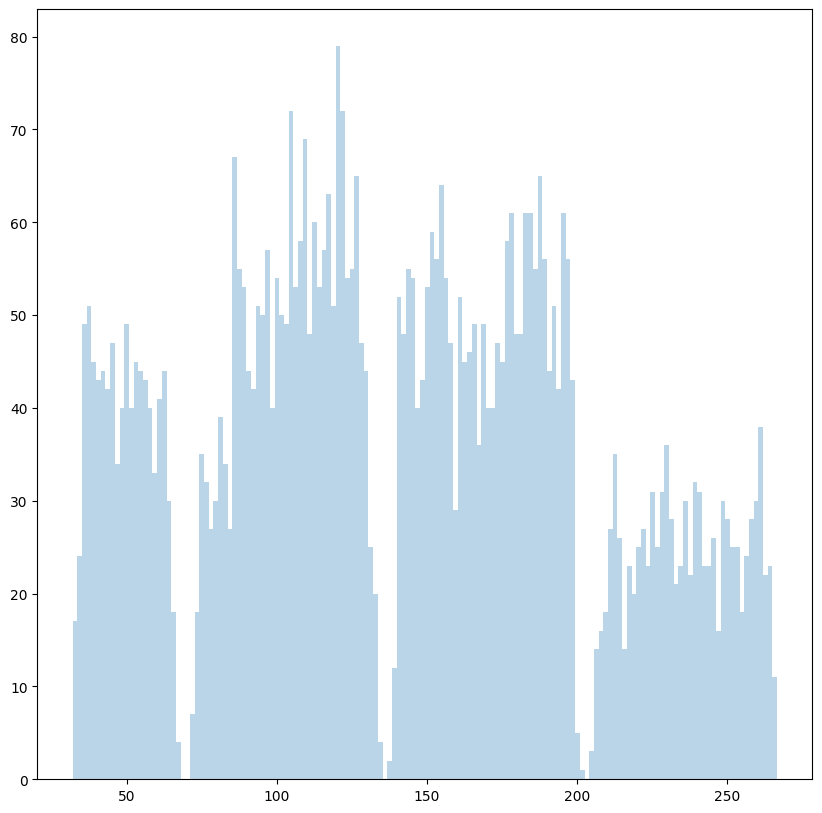

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10,10)  ## rcParams It sets global settings for all plots
plt.hist(train["Item_Outlet_Sales"],bins = 100)

plt.hist(train["Item_MRP"],alpha = 0.3,bins = 150)  # Plot histogram of Item_MRP (price) with transparency
plt.show()

plt.rcParams['figure.figsize'] = (10,10)
plt.hist(test["Item_MRP"],alpha = 0.3,bins = 150)
plt.show()

"I used histograms to understand the distribution, skewness, and spread of numerical features, which helps in detecting outliers and deciding preprocessing techniques."

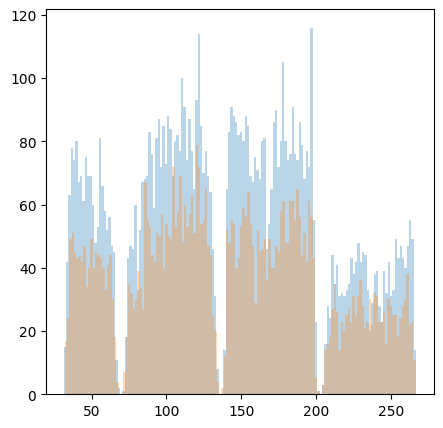

In [ ]:
plt.rcParams['figure.figsize'] = (5,5)
plt.hist(train["Item_MRP"],alpha = 0.3,bins = 150)
plt.hist(test["Item_MRP"],alpha = 0.3,bins = 150)
plt.show()

/tmp/ipykernel_2628/2408808166.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(train["Outlet_Location_Type"],palette = 'dark')  ## dark & pastel Seaborn palette name.
/tmp/ipykernel_2628/2408808166.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(test["Outlet_Location_Type"],palette = 'pastel')


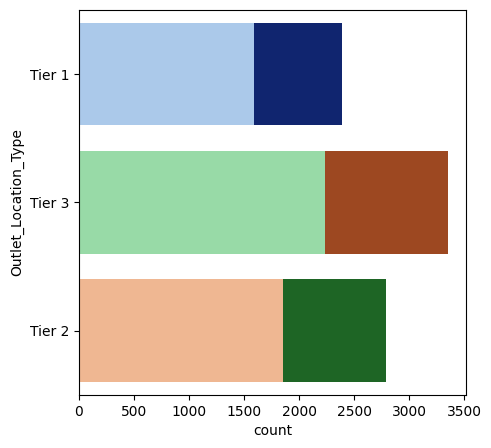

In [ ]:
sns.countplot(train["Outlet_Location_Type"],palette = 'dark')  ## dark & pastel Seaborn palette name.
sns.countplot(test["Outlet_Location_Type"],palette = 'pastel')
plt.show()

/tmp/ipykernel_2628/3937290599.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(train["Outlet_Size"],palette = 'dark')
/tmp/ipykernel_2628/3937290599.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(test["Outlet_Size"],palette = 'pastel')


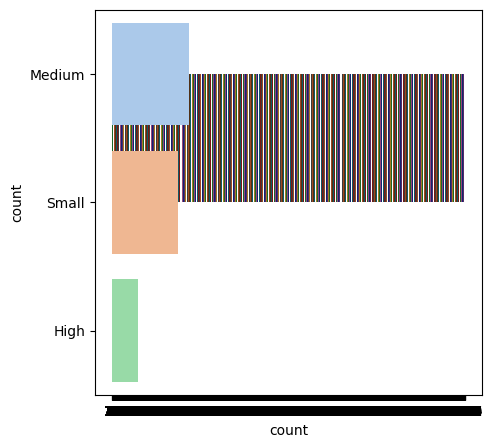

In [22]:
sns.countplot(train["Outlet_Size"],palette = 'dark')
sns.countplot(test["Outlet_Size"],palette = 'pastel')
plt.show()

/tmp/ipykernel_1710/2257902637.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(train["Outlet_Type"],palette = 'RdYlGn')
/tmp/ipykernel_1710/2257902637.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(test["Outlet_Type"],palette = 'dark')


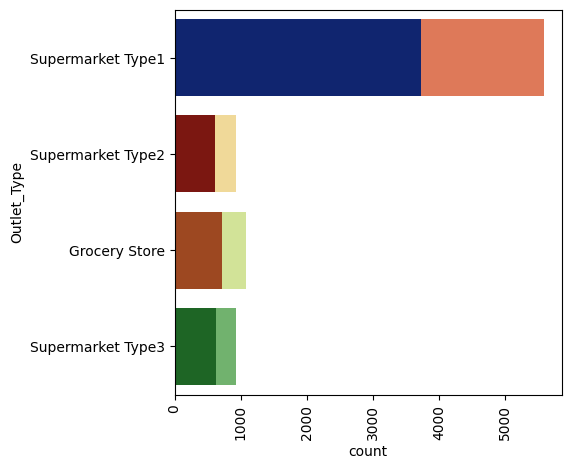

In [ ]:
sns.countplot(train["Outlet_Type"],palette = 'RdYlGn')
sns.countplot(test["Outlet_Type"],palette = 'dark')
plt.xticks(rotation = 90)
plt.show()

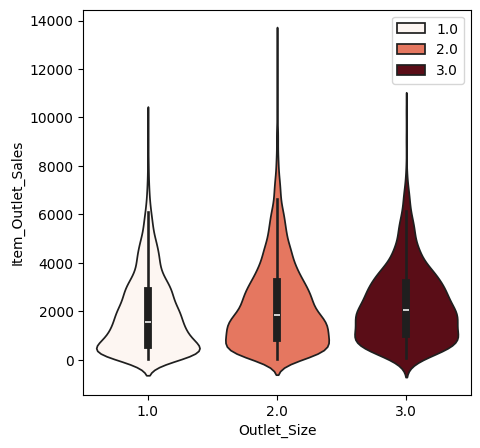

In [ ]:
sns.violinplot(x=train["Outlet_Size"],y=train["Item_Outlet_Sales"],hue = train["Outlet_Size"],palette = "Reds")
plt.legend()
plt.show()

"I used a violin plot to visualize the distribution and density of sales across different outlet sizes, which helps in understanding how sales vary across categories."

In [ ]:
train.drop(labels = ["Outlet_Establishment_Year"],inplace = True,axis =1)
test.drop(labels = ["Outlet_Establishment_Year"],inplace = True,axis =1)

In [ ]:
feat = ['Outlet_Size','Outlet_Type','Outlet_Location_Type','Item_Fat_Content',"Item_Type"]
X = pd.get_dummies(train[feat])
train = pd.concat([train,X],axis=1)


"I used one-hot encoding to convert categorical variables into binary features, ensuring the model does not assume any ordinal relationship between categories."

In [ ]:
train.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type,...,Item_Type_Fruits and Vegetables,Item_Type_Hard Drinks,Item_Type_Health and Hygiene,Item_Type_Household,Item_Type_Meat,Item_Type_Others,Item_Type_Seafood,Item_Type_Snack Foods,Item_Type_Soft Drinks,Item_Type_Starchy Foods
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,2.0,Tier 1,Supermarket Type1,...,False,False,False,False,False,False,False,False,False,False
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2.0,Tier 3,Supermarket Type2,...,False,False,False,False,False,False,False,False,True,False
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,2.0,Tier 1,Supermarket Type1,...,False,False,False,False,True,False,False,False,False,False
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,2.0,Tier 3,Grocery Store,...,True,False,False,False,False,False,False,False,False,False
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,3.0,Tier 3,Supermarket Type1,...,False,False,False,True,False,False,False,False,False,False


In [ ]:
feat = ['Outlet_Size','Outlet_Type','Outlet_Location_Type','Item_Fat_Content',"Item_Type"]
X1 = pd.get_dummies(test[feat])
test = pd.concat([test,X1],axis=1)

In [ ]:
train.drop(labels = ["Outlet_Size",'Outlet_Location_Type',"Outlet_Type",'Item_Fat_Content','Outlet_Identifier','Item_Identifier',"Item_Type"],axis=1,inplace = True)
test.drop(labels = ["Outlet_Size",'Outlet_Location_Type',"Outlet_Type",'Item_Fat_Content','Outlet_Identifier','Item_Identifier',"Item_Type"],axis=1,inplace = True)

In [ ]:
X_train = train.drop(labels = ["Item_Outlet_Sales"],axis=1)
y_train = train["Item_Outlet_Sales"]
X_train.shape,y_train.shape

((8523, 31), (8523,))

In [ ]:
train.head()

,Item_Weight,Item_Visibility,Item_MRP,Item_Outlet_Sales,Outlet_Type_Grocery Store,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3,Outlet_Location_Type_Tier 1,Outlet_Location_Type_Tier 2,...,Item_Type_Fruits and Vegetables,Item_Type_Hard Drinks,Item_Type_Health and Hygiene,Item_Type_Household,Item_Type_Meat,Item_Type_Others,Item_Type_Seafood,Item_Type_Snack Foods,Item_Type_Soft Drinks,Item_Type_Starchy Foods
0,9.30,0.016047,249.8092,3735.1380,False,True,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1,5.92,0.019278,48.2692,443.4228,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,17.50,0.016760,141.6180,2097.2700,False,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
3,19.20,0.000000,182.0950,732.3800,True,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
4,8.93,0.000000,53.8614,994.7052,False,True,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False


In [ ]:
y_train.head()

,Item_Outlet_Sales
0,3735.1380
1,443.4228
2,2097.2700
3,732.3800
4,994.7052


In [ ]:
from sklearn import preprocessing

x = X_train.values #returns a numpy array
test_s = test.values
min_max_scaler = preprocessing.MinMaxScaler()
x_scaled_train = min_max_scaler.fit_transform(x)
x_scaled_test = min_max_scaler.fit_transform(test_s)
df_train = pd.DataFrame(x_scaled_train)
df_test = pd.DataFrame(x_scaled_test)

In [ ]:
df_train.head()

,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,30
0,0.282525,0.048866,0.927507,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.081274,0.058705,0.072068,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.770765,0.051037,0.468288,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0.871986,0.000000,0.640093,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.260494,0.000000,0.095805,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df_train, y_train, test_size=0.4)

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [ ]:
preds = model.predict(X_test)

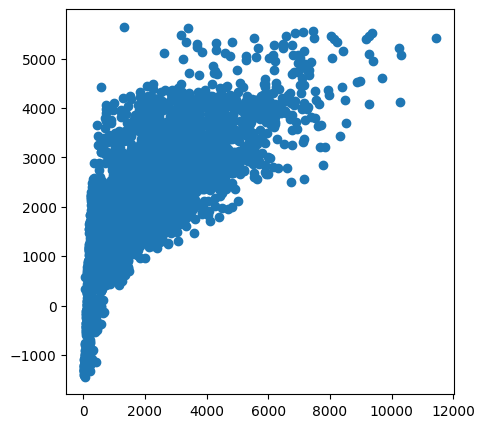

In [ ]:
plt.scatter(y_test, preds)
plt.show()

/tmp/ipykernel_1710/314155612.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((y_test-preds),bins=50)


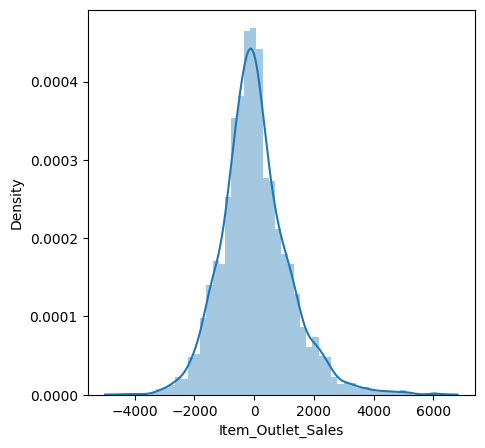

In [ ]:
sns.distplot((y_test-preds),bins=50)
plt.show()

"I plotted residuals to check whether the errors follow a normal distribution centered around zero, which indicates that the model is unbiased and performs well."

In [ ]:
from sklearn import metrics
print("MAE:", metrics.mean_absolute_error(y_test, preds))
print('MSE:', metrics.mean_squared_error(y_test, preds))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, preds)))

MAE: 848.6476062351906
MSE: 1308527.5096426313
RMSE: 1143.9088729626287


In [ ]:
predictions = model.predict(df_test)
final = pd.DataFrame({"Item_Identifier":test1["Item_Identifier"],"Outlet_Identifier":test1["Outlet_Identifier"],"Item_Outlet_Sales":abs(predictions)})
final.head()

,Item_Identifier,Outlet_Identifier,Item_Outlet_Sales
0,FDW58,OUT049,1718.696245
1,FDW14,OUT017,1335.092302
2,NCN55,OUT010,1868.284338
3,FDQ58,OUT017,2518.540751
4,FDY38,OUT027,5074.254609


In [ ]:
final.to_csv('Submiss1.csv',index=False,header=True)